In [11]:
!pip install -q pandas matplotlib numpy

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('jakarta_house.csv')
df.head()

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


In [14]:
#pengecekan dimensi

df.shape

(10000, 9)

In [15]:
#pengecekan tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  str    
 3   city           10000 non-null  str    
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), str(2)
memory usage: 937.6 KB


In [16]:
#untuk tau data yang hilang
df.isnull().sum()

index            0
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

In [17]:
#Ringkasan statistik
df.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


In [20]:
print(df.columns.tolist())

['index', 'price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']


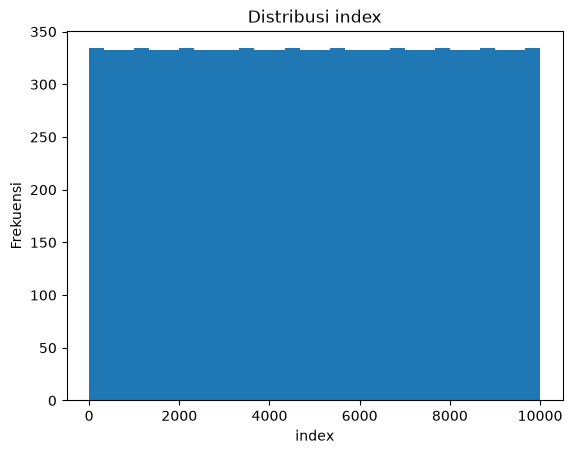

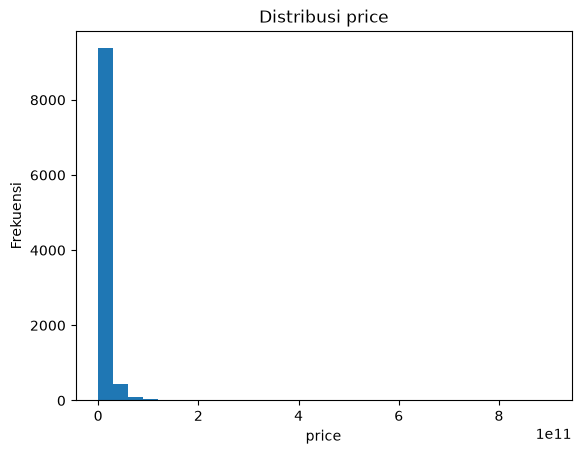

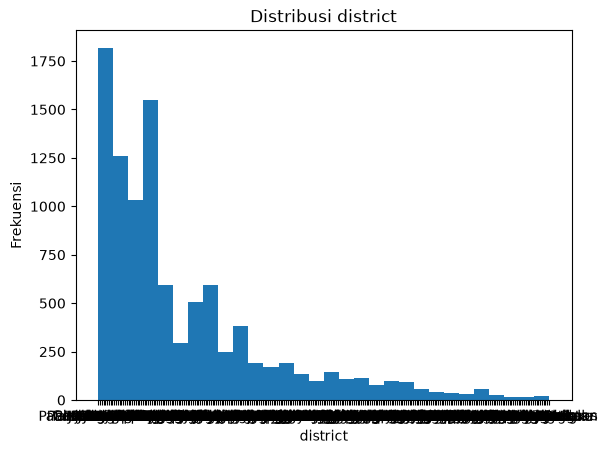

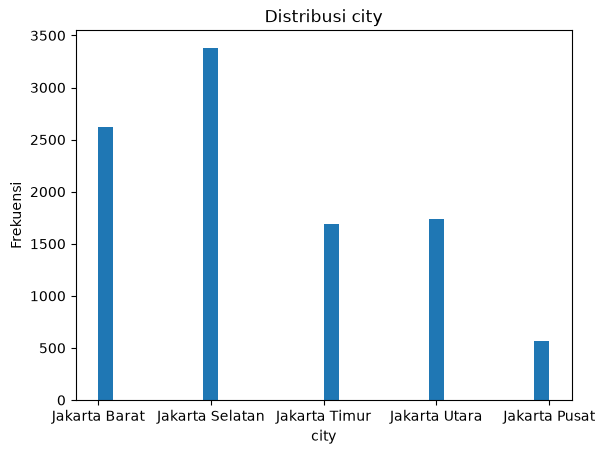

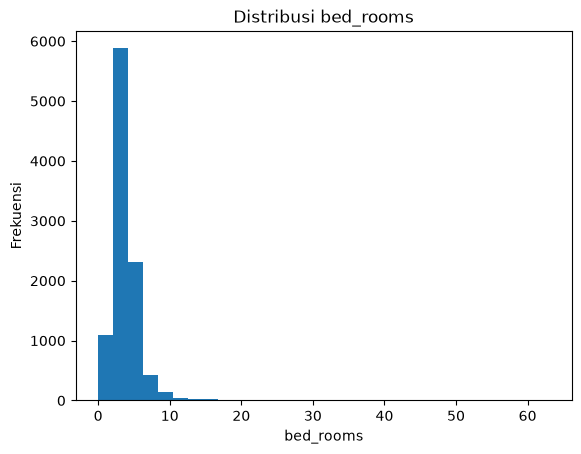

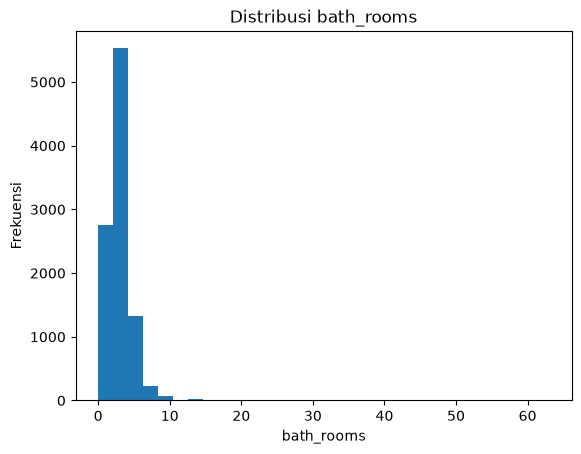

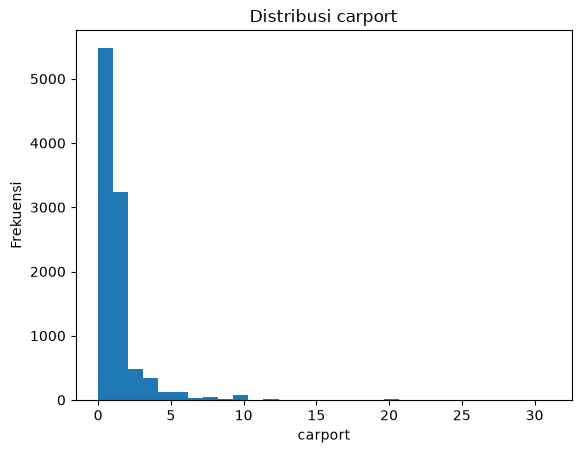

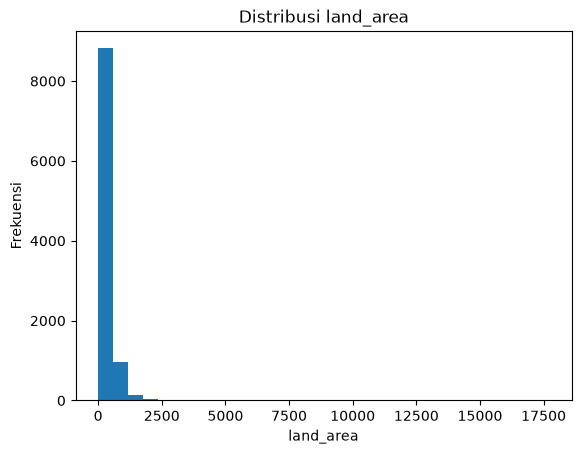

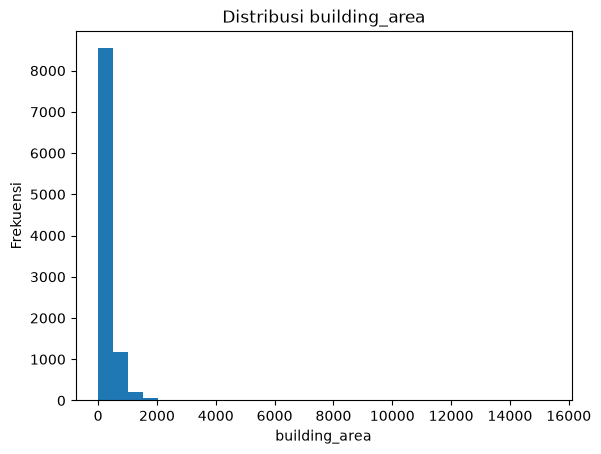

In [22]:
#Inspeksi distribusi data
num_cols = ['index', 'price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col); plt.ylabel('Frekuensi')
    plt.show()

C:\Users\ADVAn\AppData\Local\Temp\ipykernel_5020\3391397549.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['price'].dropna(), vert=True)


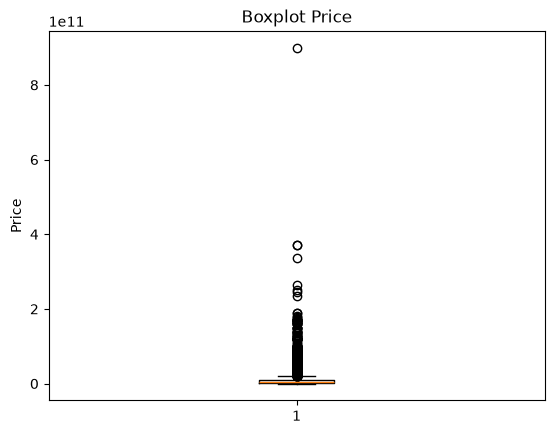

In [23]:
#inspeksi outlier
plt.figure()
plt.boxplot(df['price'].dropna(), vert=True)
plt.title('Boxplot Price')
plt.ylabel('Price')
plt.show()

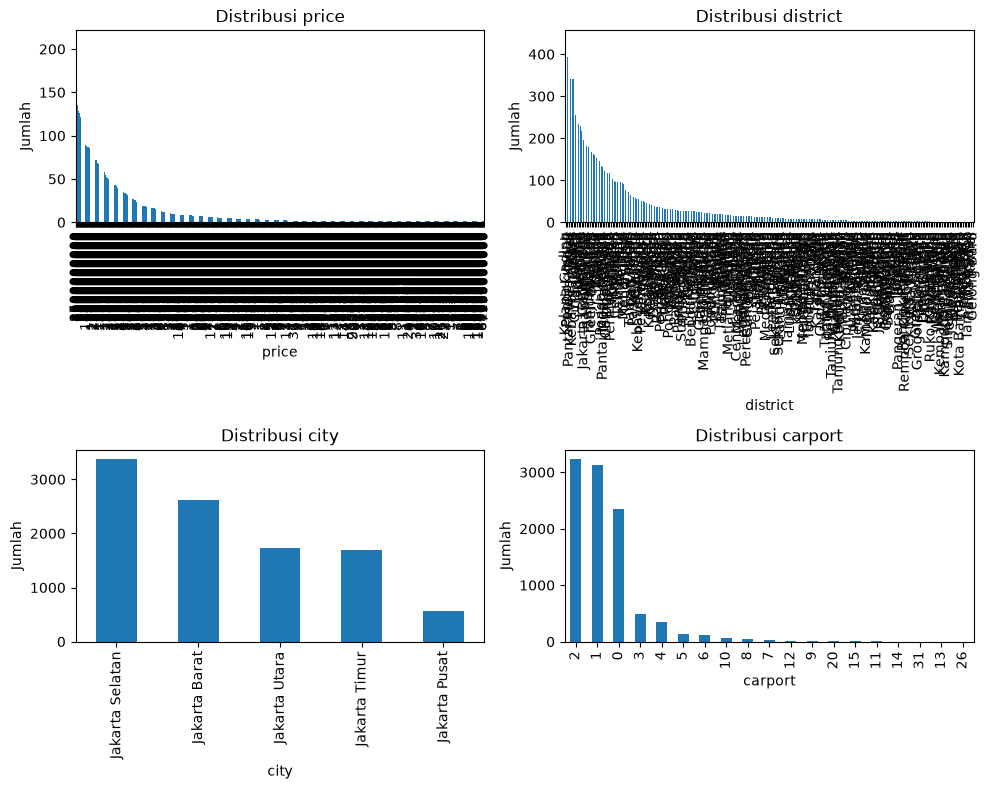

In [25]:
#Inspeksi Komposisi Variabel Kualitatif

cat_cols = ['price', 'district', 'city', 'carport']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

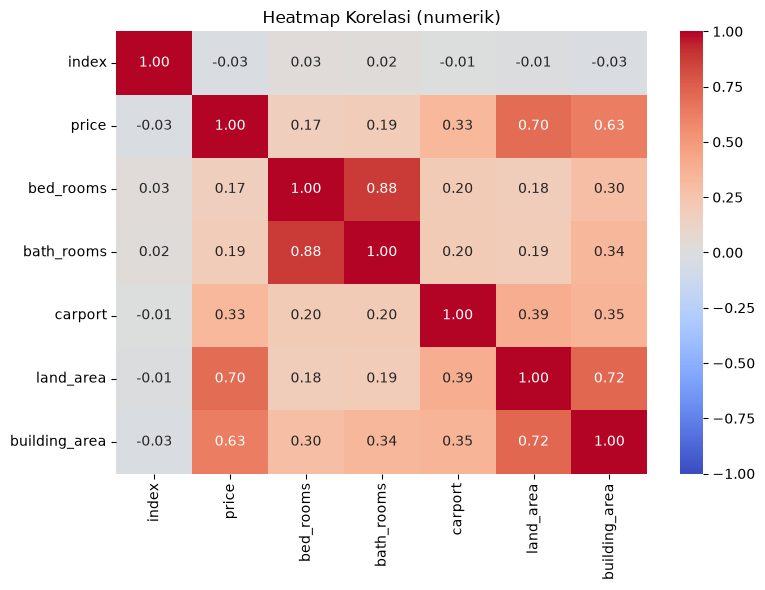

In [26]:
#heatmap
import seaborn as sns # Import seaborn for enhanced visualization

num_only = df.select_dtypes(include=[np.number])
corr = num_only.corr(numeric_only=True)

plt.figure(figsize=(8, 6)) # Increased figure size for better readability
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f") # Use seaborn.heatmap with annotation
plt.title('Heatmap Korelasi (numerik)')
plt.tight_layout()
plt.show()

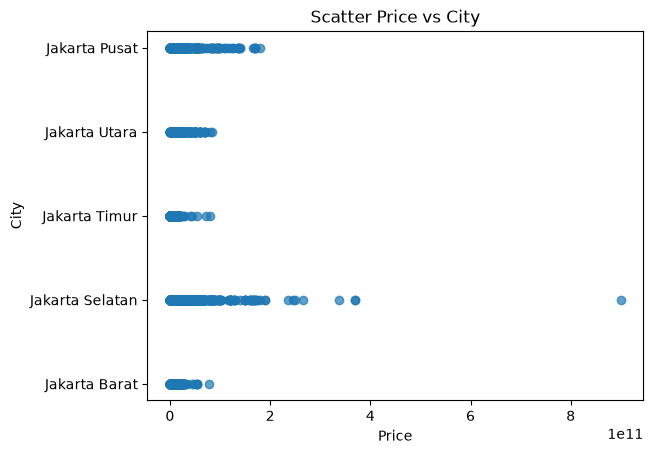

In [27]:
#scatter plot

plt.figure()
surv_map = {0:'No', 1:'Yes'}
plt.scatter(df['price'], df['city'], alpha=0.7)
plt.xlabel('Price'); plt.ylabel('City')
plt.title('Scatter Price vs City')
plt.show()